# Hard Istance Max Cut with different annealing methods

#### Imports

In [70]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from src.annealing_utils import (
    get_driver_hamiltonian,
    get_longitudinal_hamiltonian,
    computational_basis,
)
from src.schedule_utils import SchedulerModel, Schedule
from ManyBodyQutip.qutip_class import SpinOperator
from src.utils import Sector
import pickle

In [71]:
def plot_instance_graph(jij, ax=None, title=None):
    nqubits = jij.shape[0]

    G = nx.Graph()
    G.add_nodes_from(range(nqubits))

    for i in range(nqubits):
        for j in range(i + 1, nqubits):
            if abs(jij[i, j]) > 1e-10:
                G.add_edge(i, j, weight=jij[i, j])

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    pos = nx.circular_layout(G)
    weights = [G[u][v]["weight"] for u, v in G.edges()]

    # colour edges by weight (positive=red, negative=blue)
    edge_colors = ["red" if w > 0 else "blue" for w in weights]
    edge_widths = [abs(w) * 3 for w in weights]

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color="k", node_size=400)
    nx.draw_networkx_labels(G, pos, ax=ax, font_color="white", font_size=10)
    nx.draw_networkx_edges(
        G, pos, ax=ax, edge_color=edge_colors, width=edge_widths, alpha=0.8
    )
    edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax, font_size=7)

    if title:
        ax.set_title(title, fontsize=10)
    ax.axis("off")

## Initialization of the target Hamiltonian

#### Hyperapameters

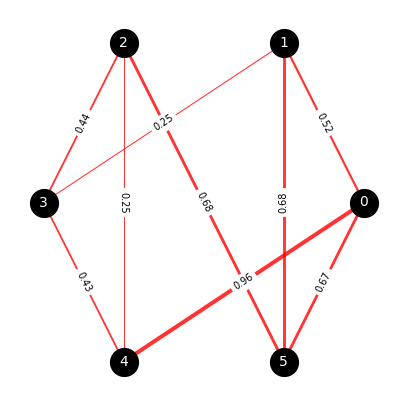

In [72]:
# ── load ──────────────────────────────────────────────────────────────────────
with open("data/hard_instances.pkl", "rb") as f:
    results = pickle.load(f)  # list of dicts, sorted hardest first

jij = results[4]["jij"]
nqubits = jij.shape[0]
plot_instance_graph(jij)

basis = computational_basis(nqubits)

#### Hamiltonian Initialization

In [73]:
nqubits = jij.shape[0]

PS = Sector(nqubits=nqubits)

target_hamiltonian = get_longitudinal_hamiltonian(jij)
target_hamiltonian_s = PS.project(target_hamiltonian)
driver_hamiltonian = get_driver_hamiltonian(nqubits=nqubits)

driver_hamiltonian_s = PS.project(driver_hamiltonian)

Sector: 32 states out of 64


#### Analysis of the spectrum of the target hamiltonian

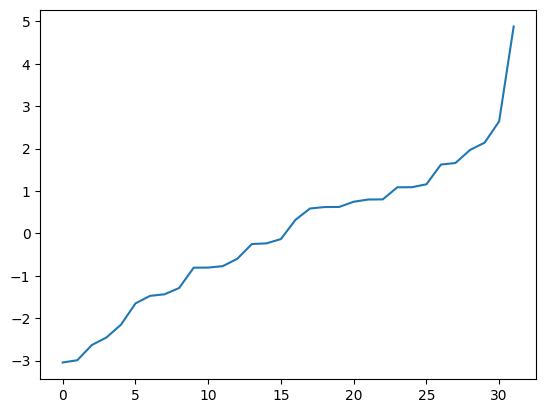

(-3.045592017227931+0j) (-2.99249295335339+0j) [0 1 1 0 1 0] [0 0 0 1 1 1]


In [74]:
values = target_hamiltonian_s.diagonal()

spectrum_target_hamiltonian_s = np.sort(values)
eigenstates_target_hamiltonian_s = basis[np.argsort(values)]

plt.plot(spectrum_target_hamiltonian_s)
plt.show()

print(
    spectrum_target_hamiltonian_s[0],
    spectrum_target_hamiltonian_s[1],
    eigenstates_target_hamiltonian_s[0],
    eigenstates_target_hamiltonian_s[1],
)

#### Time evolution

In [ ]:
# ── time evolution parameters ─────────────────────────────────────────────────
nlevels = 10
tau = 40
time_steps = int(10 * tau)
time = np.linspace(0, tau, time_steps)
delta_t = time[1] - time[0]

In [77]:
from scipy.sparse.linalg import eigsh, expm_multiply

# ── initial state ─────────────────────────────────────────────────────────────
dim = 2**nqubits
psi_init = np.ones(dim, dtype=complex) / np.sqrt(dim)
psi_init = PS.project(psi_init)
print(psi_init.shape)
# ── initialization ────────────────────────────────────────────────────────────
spectrum = np.zeros((time_steps, nlevels))
energy = np.zeros(time_steps)
probabilities = np.zeros((time_steps, nlevels))
psi_history = np.zeros((time_steps, dim // 2), dtype=complex)
eigenstates_history = np.zeros((time_steps, dim // 2, nlevels), dtype=complex)

eigenstates_prev = None
psi = psi_init.copy()

# ── time evolution ────────────────────────────────────────────────────────────
for i, t in enumerate(time):
    hamiltonian_t = (1 - t / tau) * driver_hamiltonian_s + (
        t / tau
    ) * target_hamiltonian_s
    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)

    # ── diagonalize ───────────────────────────────────────────────────────
    spectrum_t, eigenstates_t = eigsh(
        hamiltonian_t.astype(complex), which="SA", k=nlevels
    )
    order = np.argsort(spectrum_t)
    spectrum[i] = spectrum_t[order]
    eigenstates_raw = eigenstates_t[:, order].astype(complex)  # raw — for probabilities
    eigenstates_history[i] = eigenstates_raw
    # overlap
    probabilities[i] = (
        np.einsum("i,ia->a", psi.conj(), eigenstates_raw)
        * np.einsum("i,ia->a", psi.conj(), eigenstates_raw).conj()
    )
    energy[i] = np.real(np.vdot(psi, hamiltonian_t @ psi))
    psi_history[i] = psi

print(probabilities[-1])
print(spectrum.shape)
print(
    time[np.argmin(spectrum[:, 2] - spectrum[:, 0])],
    np.min(spectrum[:, 2] - spectrum[:, 0]),
)

min_time_gap = time[np.argmin(spectrum[:, 2] - spectrum[:, 0])]

(32,)


/tmp/ipykernel_57552/1197300001.py:34: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities[i] = (


[1.94285645e-01 4.82562089e-01 2.11813049e-01 9.18173578e-02
 1.74798830e-02 1.12828794e-03 2.77070413e-04 2.33953412e-04
 3.03722906e-04 1.19463698e-05]
(200, 10)
17.185929648241206 0.30025000471284535


Check the results

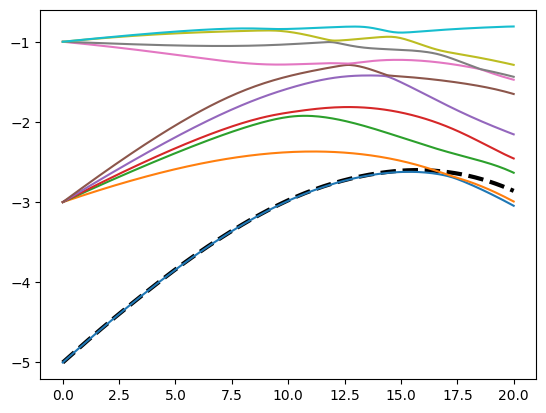

0.01349970975199044


In [78]:
plt.plot(time, energy, color="black", linestyle="--", linewidth=3)
for i in range(spectrum.shape[1]):
    plt.plot(time, spectrum[:, i])

plt.show()

delta = spectrum[:, 1] - spectrum[:, 0]

print(np.min(delta))

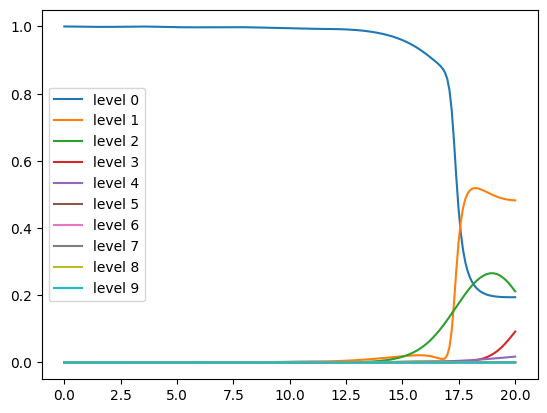

In [79]:
for i in range(nlevels):
    plt.plot(time, probabilities[:, i], label=f"level {i}")

plt.legend()
plt.show()

#### Compute Measure of Stabilizerness

In [17]:
from src.jax_utils import SREJax
from tqdm import trange

# build once — reuse for all states
sre = SREJax(n_qubits=nqubits, batch_size=4096)

# single state
magic = []
magic_gs_level = []
for i in trange(time_steps):
    state = psi_history[i]
    magic.append(sre(PS.lift(state)))
    magic_gs_level.append(sre(PS.lift(eigenstates_history[i, :, 0])))

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Building Pauli index tables for n=6 (4,096 Paulis)...
Done.


100%|██████████| 200/200 [00:00<00:00, 283.06it/s]


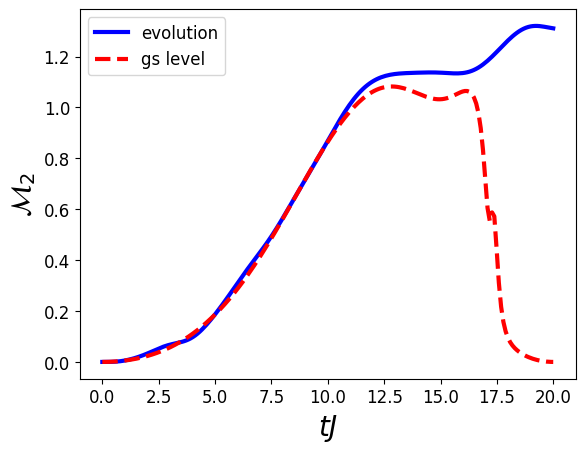

In [18]:
plt.plot(time, magic, label="evolution", color="blue", linestyle="-", linewidth=3)
plt.plot(
    time, magic_gs_level, label="gs level", color="red", linestyle="--", linewidth=3
)
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$\mathcal{M}_2$", fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()

In [19]:
from curses.ascii import SP

_, eigenstates_target_hamiltonian = eigsh(
    target_hamiltonian_s.astype(complex), which="SA", k=4
)
print(sre(PS.lift(eigenstates_target_hamiltonian[:, 0])))

-1.7763568394002505e-15


## Optimal Control Method

##### Get Hyperparameters

In [80]:
number_parameters = 32
type = "cumulative"

In [63]:
from scipy.optimize import minimize

model = SchedulerModel(
    target_hamiltonian=target_hamiltonian_s,
    initial_hamiltonian=driver_hamiltonian_s,
    tf=tau,
    nsteps=time_steps,
    number_of_parameters=number_parameters,
    type=type,
    seed=42,
    reference_hamiltonian=target_hamiltonian_s,
    mode="annealing ansatz",
)


res = minimize(
    model.forward,
    model.parameters,
    method="L-BFGS-B",
    tol=10**-6,
    callback=model.callback,
    options=None,
)

model.parameters = res.x
energy = model.forward(model.parameters)

ValueError: Unknown schedule type: 'cumulative'

#### Jax optimization (optional)

In [81]:
from src.jax_utils import JaxSchedulerModel, JaxTrainer

model = JaxSchedulerModel(
    initial_state=psi_init,
    target_hamiltonian=target_hamiltonian_s,
    initial_hamiltonian=driver_hamiltonian_s,
    reference_hamiltonian=target_hamiltonian_s,
    tf=tau,
    nsteps=time_steps,
    number_of_parameters=number_parameters,
    type=type,
    seed=42,
    mode="annealing ansatz",
    random=False,
)

trainer = JaxTrainer(model, maxiter=2000, tol=1e-9, ftol=1e-9, gtol=1e-9, verbose=True)
results = trainer.run()

h_driver = results["h_driver"]
h_target = results["h_target"]
psi_final = results["psi"]
energy = results["energy"]  # already in physical units

JIT compilation done.
-2.9383367010438186
-2.9950830171862286
-2.996164639196696
-2.9972473939901705
-3.0008260695484545
-3.0019412127101393
-3.0023256512664935
-3.0026014143958015
-3.0030646476467586
-3.003643327014823
-3.004477691328499
-3.0048536136423856
-3.004981260450562
-3.0050358552144982
-3.0051147949151655
-3.0052792927080705
-3.005318921606283
-3.0054630524508053
-3.005506850931149
-3.005570246799175
-3.005684427527918
-3.0058440418091226
-3.006153834365546
-3.0063736916408206
-3.006559466938311
-3.0066803457766946
-3.006917793380439
-3.007138501847986
-3.007310740093426
-3.0075375989372204
-3.0077698245736064
-3.0079301872852557
-3.0081799306906616
-3.0084596818154137
-3.0086003773029817
-3.0086810992700133
-3.008809868140113
-3.0088420549118555
-3.0088855768961422
-3.0089182378663044
-3.0089490659407185
-3.0089905517385422
-3.0090225995943145
-3.0090532187853247
-3.009074961245062
-3.00909435521472
-3.009112978594823
-3.0091411393763967
-3.0091756244693215
-3.0092031623656

KeyboardInterrupt: 

In [44]:
import numpy as np
import jax
import jax.numpy as jnp
from src.jax_utils import JaxSchedulerModel, JaxTrainer


def run_fcrab_warm_start(
    psi_init,
    target_hamiltonian_s,
    driver_hamiltonian_s,
    tau,
    time_steps,
    dim_schedule=[2, 4, 8, 16],  # N_c levels to iterate through
    nr=5,  # random restarts per level
    maxiter=2000,
    tol=1e-9,
    ftol=1e-9,
    gtol=1e-9,
    verbose=True,
):
    best_params = None  # Fourier coefficients [C^x(dim), C^z(dim)]
    best_omegas = None  # frequencies, shape (dim,)
    best_energy = np.inf
    best_model = None

    for level_idx, dim in enumerate(dim_schedule):
        dim_prev = dim_schedule[level_idx - 1] if level_idx > 0 else 0
        delta = dim - dim_prev

        if verbose:
            print(f"\n{'='*50}")
            print(f"  N_c = {dim}  (adding {delta} new modes, {nr} restarts)")
            print(f"{'='*50}")

        level_best_energy = np.inf
        level_best_params = None
        level_best_omegas = None
        level_best_model = None

        for restart in range(nr):
            # ── build frequency array ────────────────────────────────────────
            # old frequencies stay fixed, only new ones are randomised
            rng = np.random.default_rng()  # fresh seed each restart

            new_omegas = (
                np.pi
                * np.arange(dim_prev + 1, dim + 1)
                * (1 + rng.uniform(-0.5, 0.5, delta))
                / tau
            )

            if best_omegas is not None:
                full_omegas = np.concatenate([best_omegas, new_omegas])
            else:
                full_omegas = new_omegas  # first level: all new

            # ── build warm-start parameter vector ────────────────────────────
            # layout: [C^x_1..C^x_dim, C^z_1..C^z_dim]
            # old coefficients carried over, new ones zeroed
            init_params = np.zeros(2 * dim)
            if best_params is not None:
                init_params[:dim_prev] = best_params[:dim_prev]  # C^x old
                init_params[dim : dim + dim_prev] = best_params[dim_prev:]  # C^z old

            # ── construct model and inject frequencies ───────────────────────
            model = JaxSchedulerModel(
                initial_state=psi_init,
                target_hamiltonian=target_hamiltonian_s,
                initial_hamiltonian=driver_hamiltonian_s,
                reference_hamiltonian=target_hamiltonian_s,
                tf=tau,
                nsteps=time_steps,
                number_of_parameters=dim,
                type="F-CRAB",
                seed=42,
                mode="annealing ansatz",
                random=False,
            )

            # override omegas and recompute sin/cos bases
            model.omegas = full_omegas
            model._sin_basis = jnp.sin(
                jnp.outer(jnp.array(full_omegas), model._time_jax)
            )

            model.parameters = init_params

            # recompile jitted functions with new basis
            model._forward_jax = jax.jit(model._build_forward())
            model._grad_jax = jax.jit(jax.grad(model._build_forward()))
            # warm up
            _p = jnp.array(model.parameters)
            model._forward_jax(_p).block_until_ready()
            model._grad_jax(_p).block_until_ready()

            # ── optimize ─────────────────────────────────────────────────────
            trainer = JaxTrainer(
                model, maxiter=maxiter, tol=tol, ftol=ftol, gtol=gtol, verbose=verbose
            )
            results = trainer.run()

            if verbose:
                print(f"  restart {restart+1}/{nr}  E = {results['energy']:.6f}")

            if results["energy"] < level_best_energy:
                level_best_energy = results["energy"]
                level_best_params = model.parameters.copy()
                level_best_omegas = full_omegas.copy()
                level_best_model = model

        # ── keep best across levels ──────────────────────────────────────────
        if level_best_energy < best_energy:
            best_energy = level_best_energy
        best_params = level_best_params
        best_omegas = level_best_omegas
        best_model = level_best_model

        if verbose:
            print(f"\n  → best energy at N_c={dim}: {best_energy:.6f}")

    # final results from best model
    h_driver, h_target = best_model.get_driving()
    return {
        "h_driver": h_driver,
        "h_target": h_target,
        "energy": best_energy,
        "psi": best_model.psi,
        "parameters": best_params,
        "omegas": best_omegas,
        "model": best_model,
    }


# ── usage — drop-in replacement for your cell ────────────────────────────────
results = run_fcrab_warm_start(
    psi_init=psi_init,
    target_hamiltonian_s=target_hamiltonian_s,
    driver_hamiltonian_s=driver_hamiltonian_s,
    tau=tau,
    time_steps=time_steps,
    dim_schedule=[2, 4, 8, 16, 32],  # adjust to your N_c target
    nr=5,
    maxiter=500,
    tol=1e-6,
    ftol=1e-6,
    gtol=1e-6,
    verbose=True,
)

h_driver = results["h_driver"]
h_target = results["h_target"]
psi_final = results["psi"]
energy = results["energy"]


  N_c = 2  (adding 2 new modes, 5 restarts)
JIT compilation done.
-2.897057959857329
-2.9781139343785954
-2.987862627422101
-2.995940537367582
-2.9982064753973963
-2.999438491813785
-2.9998973956565878
-2.9999881001611226
-3.0007403131824324
-3.000767719439957
-3.0008538395075885
-3.0009597449259546
-3.0009742772755637
-3.0009901568404587
-3.0009910447902577

Optimization success : True
Final energy         : -3.000991
Message              : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  restart 1/5  E = -3.000991
JIT compilation done.
-2.9026276012089496
-2.971752533030318
-2.9856491686277677
-2.995106048569114
-2.9985809337139218
-2.999111361660632
-2.999543547723729
-3.0002897911534685
-3.0006613831602067
-3.0008003510622276
-3.0009208627414874
-3.00097489425323
-3.0010078477794995
-3.0010198749368135
-3.0010202033486157

Optimization success : True
Final energy         : -3.001020
Message              : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  restart 2/5  E 

#### Check the results

(2.2114870947998546+4.484342184705991j)


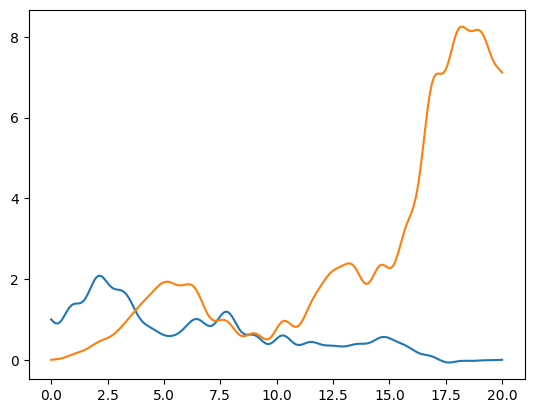

(-3.0212833176753087+0j)


In [49]:
# ── energy + state history for both schedules ─────────────────────────────────
energy_linear = np.zeros(time_steps)
energy_optimal = np.zeros(time_steps)
psi_linear_history = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
psi_optimal_history = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)

# optimal
h_driver = results["h_driver"]
h_target = results["h_target"]
psi_final = results["psi"]
energy = results["energy"]

# initialize the state
_, psi = eigsh(driver_hamiltonian_s.astype(complex), which="SA", k=1)
psi_init = psi[:, 0].astype(complex)
print(psi_init.dot(h_driver[0] * driver_hamiltonian_s.dot(psi_init)))

plt.plot(time, h_driver)
plt.plot(time, h_target)
plt.show()


# initialization
psi = psi_init.copy()
psi_history_optimalcontrol = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
for i, t in enumerate(time):

    hamiltonian_t = (
        h_driver[i] * driver_hamiltonian_s + target_hamiltonian_s * h_target[i]
    )
    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)
    psi_history_optimalcontrol[i] = psi
    # for r in range(nlevels):
    #    probabilities_optimalcontrol[i,r]=(eigenstates_history[i,:,r].conj().T.dot(psi))*np.conjugate((eigenstates_history[i,:,r].conj().T.dot(psi)))

print(psi.conj().dot(target_hamiltonian_s.dot(psi)))

In [50]:
# initialization
energy_optimal = np.zeros(time_steps)
probabilities_optimalcontrol = np.zeros((time_steps, nlevels))
spectrum_optimalcontrol = np.zeros((time_steps, nlevels))
for i, t in enumerate(time):
    psi = psi_history_optimalcontrol[i]
    hamiltonian_t = (
        1 - t / tau
    ) * driver_hamiltonian_s + target_hamiltonian_s * t / tau
    values, eigenstates = eigsh(hamiltonian_t, which="SA", k=nlevels)
    order = np.argsort(values)
    spectrum_t = values[order]
    eigenstates_t = eigenstates[:, order]
    spectrum_optimalcontrol[i] = spectrum_t
    # overlap
    probabilities_optimalcontrol[i] = (
        np.einsum("i,ia->a", psi.conj(), eigenstates_t)
        * np.einsum("i,ia->a", psi.conj(), eigenstates_t).conj()
    )
    energy_optimal[i] = psi.conj().dot(hamiltonian_t.dot(psi))
print(t)
print(psi.conj().dot(target_hamiltonian_s.dot(psi)))
print(probabilities_optimalcontrol[-1, 0])

/tmp/ipykernel_57552/3878356701.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities_optimalcontrol[i] = (
/tmp/ipykernel_57552/3878356701.py:20: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_optimal[i] = psi.conj().dot(hamiltonian_t.dot(psi))


20.0
(-3.0212833176753087+0j)
0.572730820504441


In [51]:
print(spectrum_optimalcontrol[-1])

[-3.04559202 -2.99249295 -2.63381916 -2.45572985 -2.15505433 -1.65180647
 -1.47371715 -1.43703681 -1.28836233 -0.8095975 ]


0
-3.045592017227929
1
-2.9924929533533873
2
-2.6338191635187886
3
-2.4557298517864
4
-2.155054331212787
5
-1.651806465941983
6
-1.473717154209585
7
-1.4370368053759648
8
-1.2883623327648397
9
-0.8095975004588315


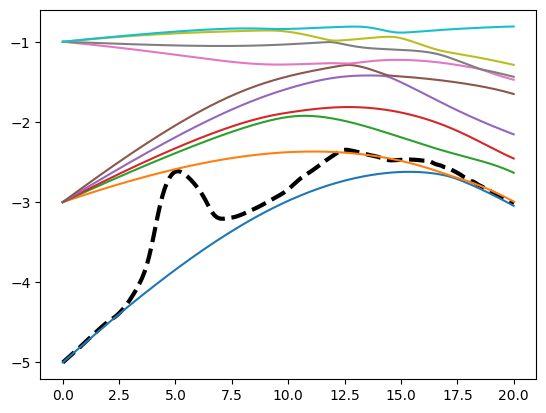

In [52]:
plt.plot(time, energy_optimal, color="black", linestyle="--", linewidth=3)
for i in range(spectrum_optimalcontrol.shape[1]):
    print(i)
    print(spectrum_optimalcontrol[-1, i])
    plt.plot(time, spectrum_optimalcontrol[:, i])

plt.show()

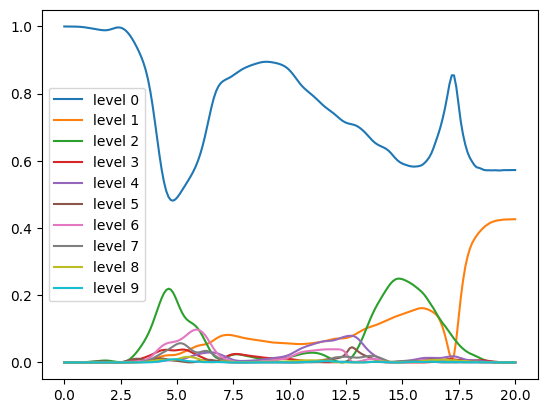

In [53]:
for i in range(nlevels):
    plt.plot(time, probabilities_optimalcontrol[:, i], label=f"level {i}")

plt.legend()
plt.show()

##### Stabilizer Renyi Entropy

In [54]:
# single state
magic_optimal_control = []
for i in trange(time_steps):
    state = psi_history_optimalcontrol[i]
    magic_optimal_control.append(sre(PS.lift(state)))

100%|██████████| 200/200 [00:00<00:00, 645.27it/s]


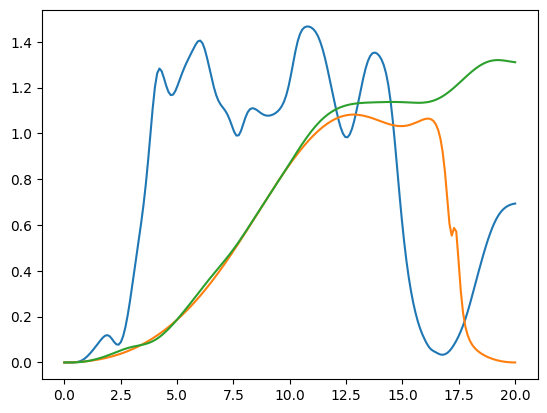

In [55]:
plt.plot(time, magic_optimal_control)
plt.plot(time, magic_gs_level)
plt.plot(time, magic)
plt.show()

## CounterAdiabatic Driving

##### We should be more careful about the CounterAdiabatic Driving, we need to be sure on the structure

Let's initialize the Catalyst term

In [93]:
from src.annealing_utils import get_unbiased_catalyst_term
from src.annealing_utils import get_counteradiabatic_term

counteradiabatic_term = get_counteradiabatic_term(
    driver_hamiltonian=driver_hamiltonian, target_hamiltonian=target_hamiltonian
)
counteradiabatic_term_s = PS.project(counteradiabatic_term)
print(counteradiabatic_term)

<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 384 stored elements and shape (64, 64)>
  Coords	Values
  (0, 1)	3.0762003529588404j
  (0, 2)	2.5390926911453766j
  (0, 4)	2.747124144988053j
  (0, 8)	3.56805088649665j
  (0, 16)	3.5065748714052027j
  (0, 32)	1.5552245513508143j
  (1, 0)	(-0-3.0762003529588404j)
  (1, 3)	2.5390926911453766j
  (1, 5)	1.3492831066128161j
  (1, 9)	2.6562838218188745j
  (1, 17)	(-0-0.3362177314594659j)
  (1, 33)	1.5552245513508138j
  (2, 0)	(-0-2.5390926911453766j)
  (2, 3)	3.0762003529588404j
  (2, 6)	1.731913770711225j
  (2, 10)	(-0-0.06495955162810851j)
  (2, 18)	3.5065748714052027j
  (2, 34)	1.1252599814616475j
  (3, 1)	(-0-2.5390926911453766j)
  (3, 2)	(-0-3.0762003529588404j)
  (3, 7)	0.3340727323359882j
  (3, 11)	(-0-0.9767266163058838j)
  (3, 19)	(-0-0.3362177314594663j)
  (3, 35)	1.1252599814616473j
  (4, 0)	(-0-2.747124144988053j)
  :	:
  (59, 63)	(-0-2.747124144988053j)
  (60, 28)	1.1252599814616473j
  (60, 44)	(-0-0.33621773145946

Compute the optimal driving of the adiabatic gauge potential from calculations

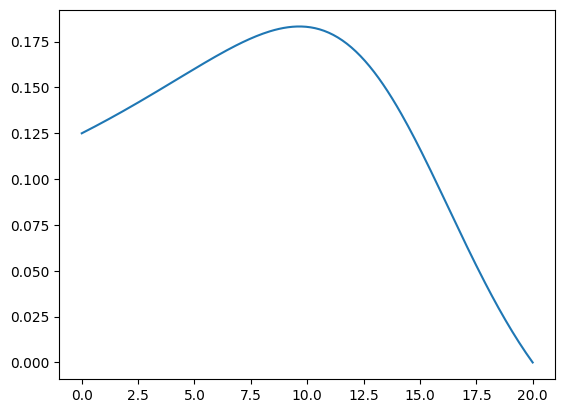

In [ ]:
def optimal_alpha(J, lam):
    """
    Optimal alpha_0(lambda) from minimizing Tr[G_lambda^2].
    """
    J2 = np.sum(J**2)  # ||J||^2
    J2_row = np.sum(J**2, axis=1)  # (n,): sum_B J_AB^2
    J4_sum = np.sum(J2_row**2)  # sum_A (sum_B J_AB^2)^2

    numerator = 4 * (1 - lam) * J2
    denominator = 32 * (1 - lam) ** 2 * J2 + 16 * lam**2 * J4_sum

    if np.abs(denominator) < 1e-12:
        return 0.0
    return -numerator / denominator


# schedule of alpha_0 along the annealing
alpha = -1 * np.array([optimal_alpha(jij, s) for s in time / tau])

plt.plot(time, alpha)
plt.show()

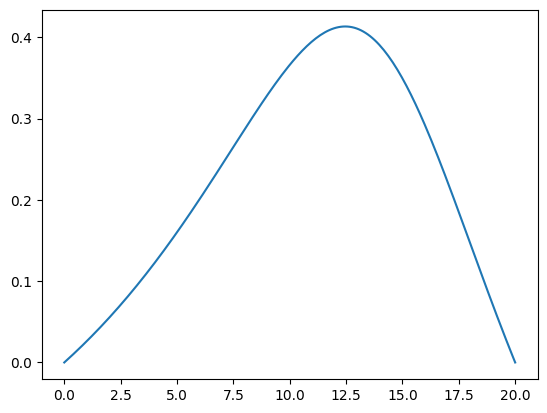

In [ ]:
def optimal_alpha(J, lam):
    """
    Optimal alpha_0(lambda) with boundary conditions enforced:
    alpha_0(0) = 0, alpha_0(1) = 0.
    """
    J2 = np.sum(J**2)
    J2_row = np.sum(J**2, axis=1)
    J4_sum = np.sum(J2_row**2)

    numerator = 4 * (1 - lam) * J2
    denominator = 32 * (1 - lam) ** 2 * J2 + 16 * lam**2 * J4_sum

    if np.abs(denominator) < 1e-12:
        return 0.0

    alpha_raw = -numerator / denominator

    # enforce boundary conditions: multiply by lambda*(1-lambda)
    return 2 * alpha_raw * lam


# schedule of alpha_0 along the annealing
alpha = -2.0 * np.array([optimal_alpha(jij, s) for s in time / tau])

plt.plot(time, alpha)
plt.show()

In [ ]:
from scipy.sparse.linalg import eigsh, expm_multiply

# ── initial state ─────────────────────────────────────────────────────────────
dim = 2**nqubits
psi_init = np.ones(dim, dtype=complex) / np.sqrt(dim)
psi_init = PS.project(psi_init)

# initialization

psi = psi_init.copy()
psi_history_counteradiabatic = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
spectrum_counteradiabatic = np.zeros((time_steps, nlevels))
energy_counteradiabatic = np.zeros(time_steps)
for i, t in enumerate(time):

    hamiltonian_t = (
        (1 - t / tau) * driver_hamiltonian_s
        + target_hamiltonian_s * t / tau
        + alpha[i] * counteradiabatic_term_s
    )
    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)
    spectrum_t, _ = eigsh(hamiltonian_t, which="SA", k=nlevels)
    order = np.argsort(spectrum_t)
    spectrum_t = spectrum_t[order]
    spectrum_counteradiabatic[i] = spectrum_t
    energy_counteradiabatic[i] = psi.conj().dot(hamiltonian_t.dot(psi))
    # sort both by eigenvalue
    psi_history_counteradiabatic[i] = psi

/tmp/ipykernel_50134/2378592107.py:22: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_counteradiabatic[i]=psi.conj().dot(hamiltonian_t.dot(psi))


In [ ]:
# initialize the state


# initialization
energy_counteradiabatic_linear_hamiltonian = np.zeros(time_steps)
probabilities_counteradiabatic = np.zeros((time_steps, nlevels))
for i, t in enumerate(time):
    psi = psi_history_counteradiabatic[i]
    hamiltonian_t_linear = (
        1 - t / tau
    ) * driver_hamiltonian_s + target_hamiltonian_s * t / tau
    values, eigenstates = eigsh(hamiltonian_t_linear, which="SA", k=nlevels)
    order = np.argsort(values)
    spectrum_t = values[order]
    eigenstates_t = eigenstates[:, order]
    # overlap
    probabilities_counteradiabatic[i] = (
        np.einsum("i,ia->a", psi.conj(), eigenstates_t)
        * np.einsum("i,ia->a", psi.conj(), eigenstates_t).conj()
    )

    energy_counteradiabatic_linear_hamiltonian[i] = psi.conj().dot(
        hamiltonian_t_linear.dot(psi)
    )
print(t)
print(psi.conj().dot(target_hamiltonian_s.dot(psi)))
print(energy_counteradiabatic_linear_hamiltonian[-1])
print(probabilities_counteradiabatic[-1, 0])

/tmp/ipykernel_50134/1932926314.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities_counteradiabatic[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_t)*np.einsum('i,ia->a',psi.conj(),eigenstates_t).conj()
/tmp/ipykernel_50134/1932926314.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_counteradiabatic_linear_hamiltonian[i]=psi.conj().dot(hamiltonian_t_linear.dot(psi))


20.0
(-2.6379952957703923+0j)
-2.6379952957703923
0.5801356034099505


##### Results of the unbiased counteradiabatic term

0
-2.743976612213183
-2.6379952957703923
1
-2.6308149152453897
-2.6379952957703923
2
-1.8499848961174574
-2.6379952957703923
3
-1.7465957812301984
-2.6379952957703923
4
-1.4912545084945674
-2.6379952957703923
5
-1.3878653936073149
-2.6379952957703923
6
-1.3348841567611416
-2.6379952957703923
7
-1.2314950418738926
-2.6379952957703923
8
-0.9054461958599026
-2.6379952957703923
9
-0.8020570809726572
-2.6379952957703923


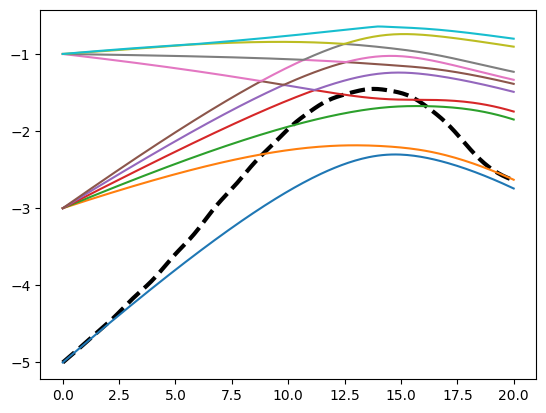

0
-2.7439766122131766
1
-2.630814915245375
2
-1.849984896117448
3
-1.7465957812302049
4
-1.491254508494568
5
-1.3878653936073184
6
-1.3348841567611403
7
-1.231495041873893
8
-0.9054461958599057
9
-0.8020570809726594


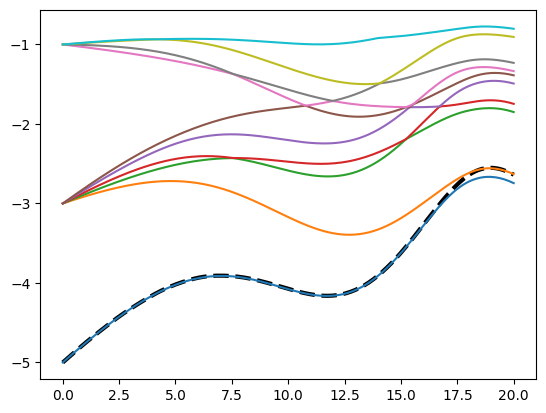

In [ ]:
plt.plot(
    time,
    energy_counteradiabatic_linear_hamiltonian,
    color="black",
    linestyle="--",
    linewidth=3,
)
for i in range(spectrum_counteradiabatic.shape[1]):
    print(i)
    print(spectrum[-1, i])
    print(energy_counteradiabatic_linear_hamiltonian[-1])
    plt.plot(time, spectrum[:, i])

plt.show()

plt.plot(time, energy_counteradiabatic, color="black", linestyle="--", linewidth=3)
for i in range(spectrum_counteradiabatic.shape[1]):

    print(i)
    print(spectrum_counteradiabatic[-1, i])
    plt.plot(time, spectrum_counteradiabatic[:, i])

plt.show()

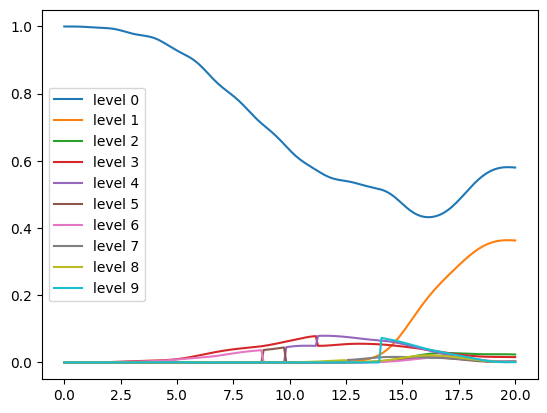

In [ ]:
for i in range(nlevels):
    plt.plot(time, probabilities_counteradiabatic[:, i], label=f"level {i}")

plt.legend()
plt.show()

##### Measure of Stabilizerness

In [ ]:
# single state
magic_counteradiabatic = []

for i in trange(time_steps):
    state = psi_history_counteradiabatic[i]
    magic_counteradiabatic.append(sre(PS.lift(state)))

100%|██████████| 200/200 [00:00<00:00, 732.40it/s]


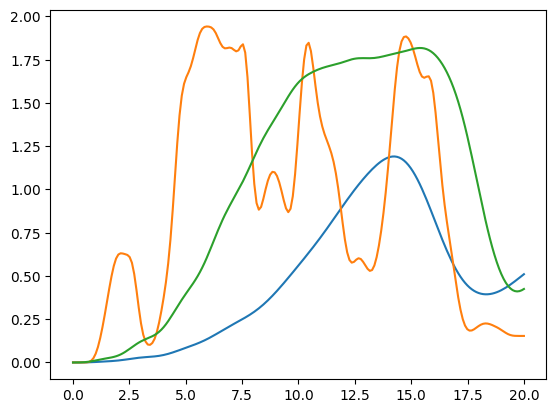

In [ ]:
plt.plot(time, magic)
plt.plot(time, magic_optimal_control)
plt.plot(time, magic_counteradiabatic)
plt.show()

## Catalyst Term

##### We should be more careful about the CounterAdiabatic Driving, we need to be sure on the structure

Let's initialize the Catalyst term

In [56]:
from src.annealing_utils import get_unbiased_catalyst_term
from src.annealing_utils import get_counteradiabatic_term
from ManyBodyQutip.qutip_class import SpinOperator

counteradiabatic_term = get_counteradiabatic_term(
    driver_hamiltonian=driver_hamiltonian, target_hamiltonian=target_hamiltonian
)
# catalyst_term=get_unbiased_catalyst_term(nqubits=nqubits)
catalyst_term = SpinOperator(
    index=[("x", 0, "x", nqubits - 2)], coupling=[1.0], size=nqubits
).qutip_op.data_as("csr_matrix")

print(counteradiabatic_term)

<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 384 stored elements and shape (64, 64)>
  Coords	Values
  (0, 1)	4.079177638433514j
  (0, 2)	3.257005682706461j
  (0, 4)	2.2383126362960337j
  (0, 8)	2.7415605015668354j
  (0, 16)	2.9118101194119617j
  (0, 32)	4.293947298999531j
  (1, 0)	(-0-4.079177638433514j)
  (1, 3)	3.2570056827064606j
  (1, 5)	2.238312636296033j
  (1, 9)	0.0023181195269348365j
  (1, 17)	0.17808931173239717j
  (1, 33)	1.6085552118519688j
  (2, 0)	(-0-3.257005682706461j)
  (2, 3)	4.079177638433513j
  (2, 6)	0.5367631015670002j
  (2, 10)	1.757229684463093j
  (2, 18)	2.911810119411961j
  (2, 34)	0.46581628541938436j
  (3, 1)	(-0-3.2570056827064606j)
  (3, 2)	(-0-4.079177638433513j)
  (3, 7)	0.5367631015669998j
  (3, 11)	(-0-0.9820126975768071j)
  (3, 19)	0.17808931173239717j
  (3, 35)	(-0-2.2195758017281775j)
  (4, 0)	(-0-2.2383126362960337j)
  :	:
  (59, 63)	(-0-2.2383126362960337j)
  (60, 28)	(-0-2.2195758017281775j)
  (60, 44)	0.17808931173239717j
  (

Tayloring the catalyst around the minimum gap

In [57]:
from scipy.sparse.linalg import eigsh, expm_multiply

# ── initial state ─────────────────────────────────────────────────────────────
dim = 2**nqubits
psi_init = np.ones(dim, dtype=complex) / np.sqrt(dim)


# initialization

psi = psi_init
psi_history_catalyst = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
spectrum_catalyst = np.zeros((time_steps, nlevels))
energy_catalyst = np.zeros(time_steps)
for i, t in enumerate(time):

    hamiltonian_t = (
        (1 - t / tau) * driver_hamiltonian
        + target_hamiltonian * t / tau
        + (1 - t / tau) * (t / tau) * catalyst_term
    )
    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)
    spectrum_t, _ = eigsh(hamiltonian_t, which="SA", k=nlevels)
    order = np.argsort(spectrum_t)
    spectrum_t = spectrum_t[order]
    spectrum_catalyst[i] = spectrum_t
    energy_catalyst[i] = psi.conj().dot(hamiltonian_t.dot(psi))
    # sort both by eigenvalue
    psi_history_catalyst[i] = psi

/tmp/ipykernel_57552/2788356127.py:26: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_catalyst[i] = psi.conj().dot(hamiltonian_t.dot(psi))


In [59]:
# initialize the state


# initialization
energy_catalyst_linear_hamiltonian = np.zeros(time_steps)
probabilities_catalyst = np.zeros((time_steps, nlevels // 2))
for i, t in enumerate(time):
    psi = psi_history_catalyst[i]
    hamiltonian_t_linear = (
        1 - t / tau
    ) * driver_hamiltonian + target_hamiltonian * t / tau
    values, eigenstates = eigsh(hamiltonian_t_linear, which="SA", k=nlevels)
    order = np.argsort(values)
    spectrum_t = values[order]
    eigenstates_t = eigenstates[:, order]
    # overlap
    overlap_t = np.einsum("i,ia->a", psi.conj(), eigenstates_t)
    for r in range(1):
        probabilities_catalyst[i, r] = np.sum(
            (
                (overlap_t[r * 2 : (r + 1) * 2])
                * (overlap_t[r * 2 : (r + 1) * 2]).conj()
            ).real
        )

    energy_catalyst_linear_hamiltonian[i] = psi.conj().dot(
        hamiltonian_t_linear.dot(psi)
    )
print(t)
print(psi.conj().dot(target_hamiltonian.dot(psi)))
print(probabilities_catalyst[-1, 0])

/tmp/ipykernel_57552/1943219520.py:26: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_catalyst_linear_hamiltonian[i] = psi.conj().dot(


20.0
(-2.8148913611810835+0j)
0.3183517634251029


##### Results of the unbiased catalyst

0
-3.0455920172279316
2
-2.633819163518779
4
-2.1550543312127903
6
-1.4737171542095813
8
-1.2883623327648375


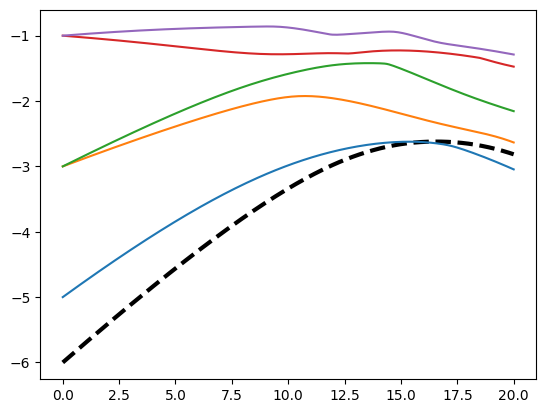

0
-3.045592017227936
2
-2.9924929533533935
4
-2.633819163518789
6
-2.4557298517864012
8
-2.1550543312127846


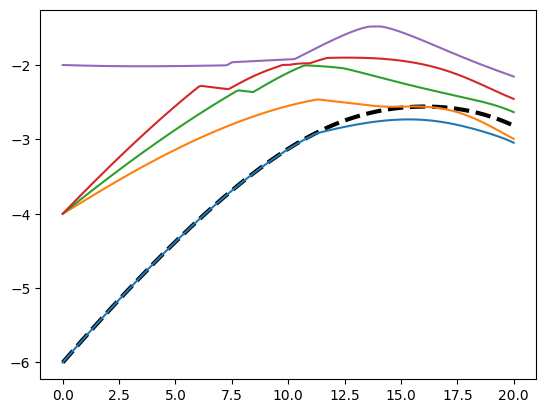

In [60]:
plt.plot(
    time, energy_catalyst_linear_hamiltonian, color="black", linestyle="--", linewidth=3
)
for i in range(spectrum_catalyst.shape[1]):
    if i % 2 == 0:
        print(i)
        print(spectrum[-1, i])
        plt.plot(time, spectrum[:, i])

plt.show()

plt.plot(time, energy_catalyst, color="black", linestyle="--", linewidth=3)
for i in range(spectrum_catalyst.shape[1]):
    if i % 2 == 0:
        print(i)
        print(spectrum_catalyst[-1, i])
        plt.plot(time, spectrum_catalyst[:, i])

plt.show()

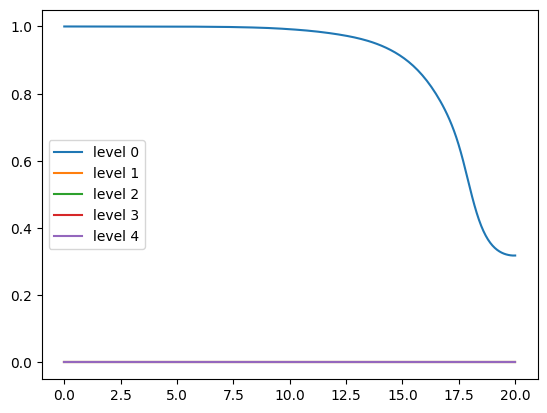

In [61]:
for i in range(nlevels // 2):
    plt.plot(time, probabilities_catalyst[:, i], label=f"level {i}")

plt.legend()
plt.show()